In [7]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Change to project root
if Path.cwd().name == "lstm":
    os.chdir("../..")
elif Path.cwd().name == "notebooks":
    os.chdir("..")

print(f"Working directory: {Path.cwd()}")

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Working directory: /home/dwijenayake/pv_forecast_30d


## 1. Load Lightning Logs (Version 02)

In [8]:
# Find all metrics.csv files for the 5 plants (no plant_04)
base_path = Path("experiments/lstm/runs/germany")
plant_ids = [f"plant_{i:02d}" for i in [1, 2, 3, 5, 6]]  # Skip plant_04

metrics_data = {}

for plant_id in plant_ids:
    plant_dir = base_path / f"pretrain_{plant_id}"
    logger_dirs = list(plant_dir.glob("germany_*_pretrain"))
    
    if logger_dirs:
        logger_dir = logger_dirs[0]
        version_dirs = list(logger_dir.glob("version_*"))
        
        if version_dirs:
            latest_version = sorted(version_dirs)[-1]
            metrics_file = latest_version / "metrics.csv"
            
            if metrics_file.exists():
                df = pd.read_csv(metrics_file)
                metrics_data[plant_id] = df
                print(f"✓ {plant_id}: {len(df)} rows from {metrics_file.relative_to(base_path)}")
            else:
                print(f"✗ No metrics.csv for {plant_id}")

print(f"\nTotal plants loaded: {len(metrics_data)}/5")

✓ plant_01: 73 rows from pretrain_plant_01/germany_plant_01_pretrain/version_0/metrics.csv
✓ plant_02: 73 rows from pretrain_plant_02/germany_plant_02_pretrain/version_0/metrics.csv
✓ plant_03: 59 rows from pretrain_plant_03/germany_plant_03_pretrain/version_0/metrics.csv
✓ plant_05: 54 rows from pretrain_plant_05/germany_plant_05_pretrain/version_0/metrics.csv
✓ plant_06: 64 rows from pretrain_plant_06/germany_plant_06_pretrain/version_0/metrics.csv

Total plants loaded: 5/5


## 2. Extract Final Validation Metrics

In [10]:
# Extract final validation loss for each plant
final_metrics = []

for plant_id, df in metrics_data.items():
    val_losses = df['val_loss'].dropna()
    train_losses = df['train_loss_epoch'].dropna()
    
    if len(val_losses) > 0:
        final_val_loss = val_losses.iloc[-1]
        final_train_loss = train_losses.iloc[-1] if len(train_losses) > 0 else np.nan
        
        # Convert MSE to RMSE
        final_val_rmse = np.sqrt(final_val_loss)
        final_train_rmse = np.sqrt(final_train_loss) if not np.isnan(final_train_loss) else np.nan
        
        final_metrics.append({
            'plant_id': plant_id,
            'val_loss_mse': final_val_loss,
            'val_rmse': final_val_rmse,
            'train_loss_mse': final_train_loss,
            'train_rmse': final_train_rmse,
            'num_epochs': len(val_losses)
        })

results_df = pd.DataFrame(final_metrics).sort_values('plant_id')

print("\n" + "="*80)
print("VERSION 02 - FINAL VALIDATION METRICS (Stratified Temporal Split)")
print("="*80)
print(results_df.to_string(index=False))
print("\n" + "="*80)

# Summary statistics
print(f"\nMean Val RMSE: {results_df['val_rmse'].mean():.6f}")
print(f"Std Val RMSE:  {results_df['val_rmse'].std():.6f}")
print(f"Min Val RMSE:  {results_df['val_rmse'].min():.6f} ({results_df.loc[results_df['val_rmse'].idxmin(), 'plant_id']})") 
print(f"Max Val RMSE:  {results_df['val_rmse'].max():.6f} ({results_df.loc[results_df['val_rmse'].idxmax(), 'plant_id']})")

# Compare to farm2107 baseline
farm2107_baseline_rmse = 0.040388
print(f"\n" + "="*80)
print(f"COMPARISON TO FARM2107 BASELINE (RMSE = {farm2107_baseline_rmse:.6f})")
print("="*80)
for _, row in results_df.iterrows():
    diff = row['val_rmse'] - farm2107_baseline_rmse
    pct_change = (diff / farm2107_baseline_rmse) * 100
    symbol = "↑" if diff > 0 else "↓"
    print(f"{row['plant_id']}: {row['val_rmse']:.6f} ({symbol} {abs(pct_change):+.2f}%)")



VERSION 02 - FINAL VALIDATION METRICS (Stratified Temporal Split)
plant_id  val_loss_mse  val_rmse  train_loss_mse  train_rmse  num_epochs
plant_01      0.013932  0.118032        0.002571    0.050701          20
plant_02      0.018153  0.134733        0.004531    0.067310          20
plant_03      0.023583  0.153568        0.004330    0.065806          20
plant_05      0.008672  0.093125        0.001443    0.037988          20
plant_06      0.022174  0.148909        0.004696    0.068526          20


Mean Val RMSE: 0.129673
Std Val RMSE:  0.024688
Min Val RMSE:  0.093125 (plant_05)
Max Val RMSE:  0.153568 (plant_03)

COMPARISON TO FARM2107 BASELINE (RMSE = 0.040388)
plant_01: 0.118032 (↑ +192.24%)
plant_02: 0.134733 (↑ +233.60%)
plant_03: 0.153568 (↑ +280.23%)
plant_05: 0.093125 (↑ +130.58%)
plant_06: 0.148909 (↑ +268.70%)


## 3. Train vs Validation Gap (Overfitting Check) - KEY DIAGNOSTIC

In [11]:
# Calculate train-val gap
results_df['train_val_gap'] = results_df['val_rmse'] - results_df['train_rmse']
results_df['train_val_ratio'] = results_df['val_rmse'] / results_df['train_rmse']

print("\n" + "="*80)
print("TRAIN vs VALIDATION GAP (Version 02 - Stratified Split)")
print("="*80)
print("Expected: Ratio in 1.0-1.3 range (normal overfitting)")
print("Version 01 Problem: Ratios 0.22-1.47 (validation easier OR harder than train)\n")

for _, row in results_df.iterrows():
    ratio = row['train_val_ratio']
    
    # Color code the assessment
    if 1.0 <= ratio <= 1.3:
        status = "✓ NORMAL"
    elif ratio < 1.0:
        status = "⚠ VAL EASIER" 
    else:
        status = "⚠ HIGH OVERFITTING"
    
    print(f"{row['plant_id']}: Train={row['train_rmse']:.6f}, Val={row['val_rmse']:.6f}, "
          f"Ratio={ratio:.3f} {status}")

print(f"\nMean Train/Val Ratio: {results_df['train_val_ratio'].mean():.3f}")
print(f"Std Train/Val Ratio:  {results_df['train_val_ratio'].std():.3f}")

# Check if ratios are in expected range
normal_count = ((results_df['train_val_ratio'] >= 1.0) & (results_df['train_val_ratio'] <= 1.3)).sum()
print(f"\n{normal_count}/5 plants have NORMAL train/val ratios (1.0-1.3)")

if normal_count == 5:
    print("✅ SUCCESS: All plants show normal generalization behavior!")
elif normal_count >= 3:
    print("⚠ ACCEPTABLE: Most plants show normal behavior")
else:
    print("❌ PROBLEM: Stratified split may not have fully resolved the issue")


TRAIN vs VALIDATION GAP (Version 02 - Stratified Split)
Expected: Ratio in 1.0-1.3 range (normal overfitting)
Version 01 Problem: Ratios 0.22-1.47 (validation easier OR harder than train)

plant_01: Train=0.050701, Val=0.118032, Ratio=2.328 ⚠ HIGH OVERFITTING
plant_02: Train=0.067310, Val=0.134733, Ratio=2.002 ⚠ HIGH OVERFITTING
plant_03: Train=0.065806, Val=0.153568, Ratio=2.334 ⚠ HIGH OVERFITTING
plant_05: Train=0.037988, Val=0.093125, Ratio=2.451 ⚠ HIGH OVERFITTING
plant_06: Train=0.068526, Val=0.148909, Ratio=2.173 ⚠ HIGH OVERFITTING

Mean Train/Val Ratio: 2.258
Std Train/Val Ratio:  0.174

0/5 plants have NORMAL train/val ratios (1.0-1.3)
❌ PROBLEM: Stratified split may not have fully resolved the issue


## 4. Power Distribution Analysis (std_ratio Check)

In [12]:
# Analyze power_norm statistics for train vs val splits
data_dir = Path("data/processed/pretraining/germany")
power_stats = []

for i in [1, 2, 3, 5, 6]:  # Skip plant_04
    plant_id = f"plant_{i:02d}"
    plant_dir = data_dir / plant_id
    
    train_file = plant_dir / "train.parquet"
    val_file = plant_dir / "val.parquet"
    
    if train_file.exists() and val_file.exists():
        train_df = pd.read_parquet(train_file)
        val_df = pd.read_parquet(val_file)
        
        train_power = train_df['power_norm']
        val_power = val_df['power_norm']
        
        power_stats.append({
            'plant_id': plant_id,
            'train_mean': train_power.mean(),
            'val_mean': val_power.mean(),
            'train_std': train_power.std(),
            'val_std': val_power.std(),
            'train_zeros': (train_power == 0).sum() / len(train_power) * 100,
            'val_zeros': (val_power == 0).sum() / len(val_power) * 100,
        })

power_df = pd.DataFrame(power_stats)
power_df['std_ratio'] = power_df['val_std'] / power_df['train_std']
power_df['mean_diff_%'] = abs(power_df['val_mean'] - power_df['train_mean']) / power_df['train_mean'] * 100

print("\n" + "="*80)
print("POWER DISTRIBUTION: TRAIN vs VALIDATION (Version 02)")
print("="*80)
print(power_df.to_string(index=False))
print("\n" + "="*80)

print("\nInterpretation:")
print("- std_ratio in [0.9, 1.1]: BALANCED difficulty (EXPECTED in Version 02)")
print("- std_ratio < 0.8: Val EASIER (Version 01 problem)")
print("- std_ratio > 1.2: Val HARDER\n")

for _, row in power_df.iterrows():
    if 0.9 <= row['std_ratio'] <= 1.1:
        print(f"✓ {row['plant_id']}: std_ratio={row['std_ratio']:.3f} - BALANCED")
    elif row['std_ratio'] < 0.8:
        print(f"🚨 {row['plant_id']}: std_ratio={row['std_ratio']:.3f} - Val MUCH easier (Version 01 pattern!)")
    elif row['std_ratio'] < 0.9:
        print(f"⚠ {row['plant_id']}: std_ratio={row['std_ratio']:.3f} - Val slightly easier")
    elif row['std_ratio'] > 1.2:
        print(f"⚠ {row['plant_id']}: std_ratio={row['std_ratio']:.3f} - Val harder")
    else:
        print(f"✓ {row['plant_id']}: std_ratio={row['std_ratio']:.3f} - Acceptable")

# Check overall balance
balanced_count = ((power_df['std_ratio'] >= 0.9) & (power_df['std_ratio'] <= 1.1)).sum()
print(f"\n{balanced_count}/5 plants have BALANCED std_ratios (0.9-1.1)")

if balanced_count == 5:
    print("✅ SUCCESS: Stratified split achieved balanced seasonal representation!")
elif balanced_count >= 3:
    print("⚠ PARTIAL SUCCESS: Most plants balanced")
else:
    print("❌ ISSUE: Stratified split did not fully balance difficulty")


POWER DISTRIBUTION: TRAIN vs VALIDATION (Version 02)
plant_id  train_mean  val_mean  train_std  val_std  train_zeros  val_zeros  std_ratio  mean_diff_%
plant_01    0.094337  0.095716   0.171257 0.173074    51.306977  51.307934   1.010612     1.462120
plant_02    0.115290  0.115496   0.191891 0.191647    47.562677  47.802019   0.998731     0.178820
plant_03    0.124297  0.121719   0.223055 0.220540    53.389207  52.910861   0.988723     2.074335
plant_05    0.071456  0.072663   0.126979 0.125929    50.354648  50.050556   0.991732     1.688749
plant_06    0.112913  0.116257   0.211334 0.212889    51.781527  51.254371   1.007358     2.962053


Interpretation:
- std_ratio in [0.9, 1.1]: BALANCED difficulty (EXPECTED in Version 02)
- std_ratio < 0.8: Val EASIER (Version 01 problem)
- std_ratio > 1.2: Val HARDER

✓ plant_01: std_ratio=1.011 - BALANCED
✓ plant_02: std_ratio=0.999 - BALANCED
✓ plant_03: std_ratio=0.989 - BALANCED
✓ plant_05: std_ratio=0.992 - BALANCED
✓ plant_06: std_ratio=1.

## 5. Training Convergence Curves

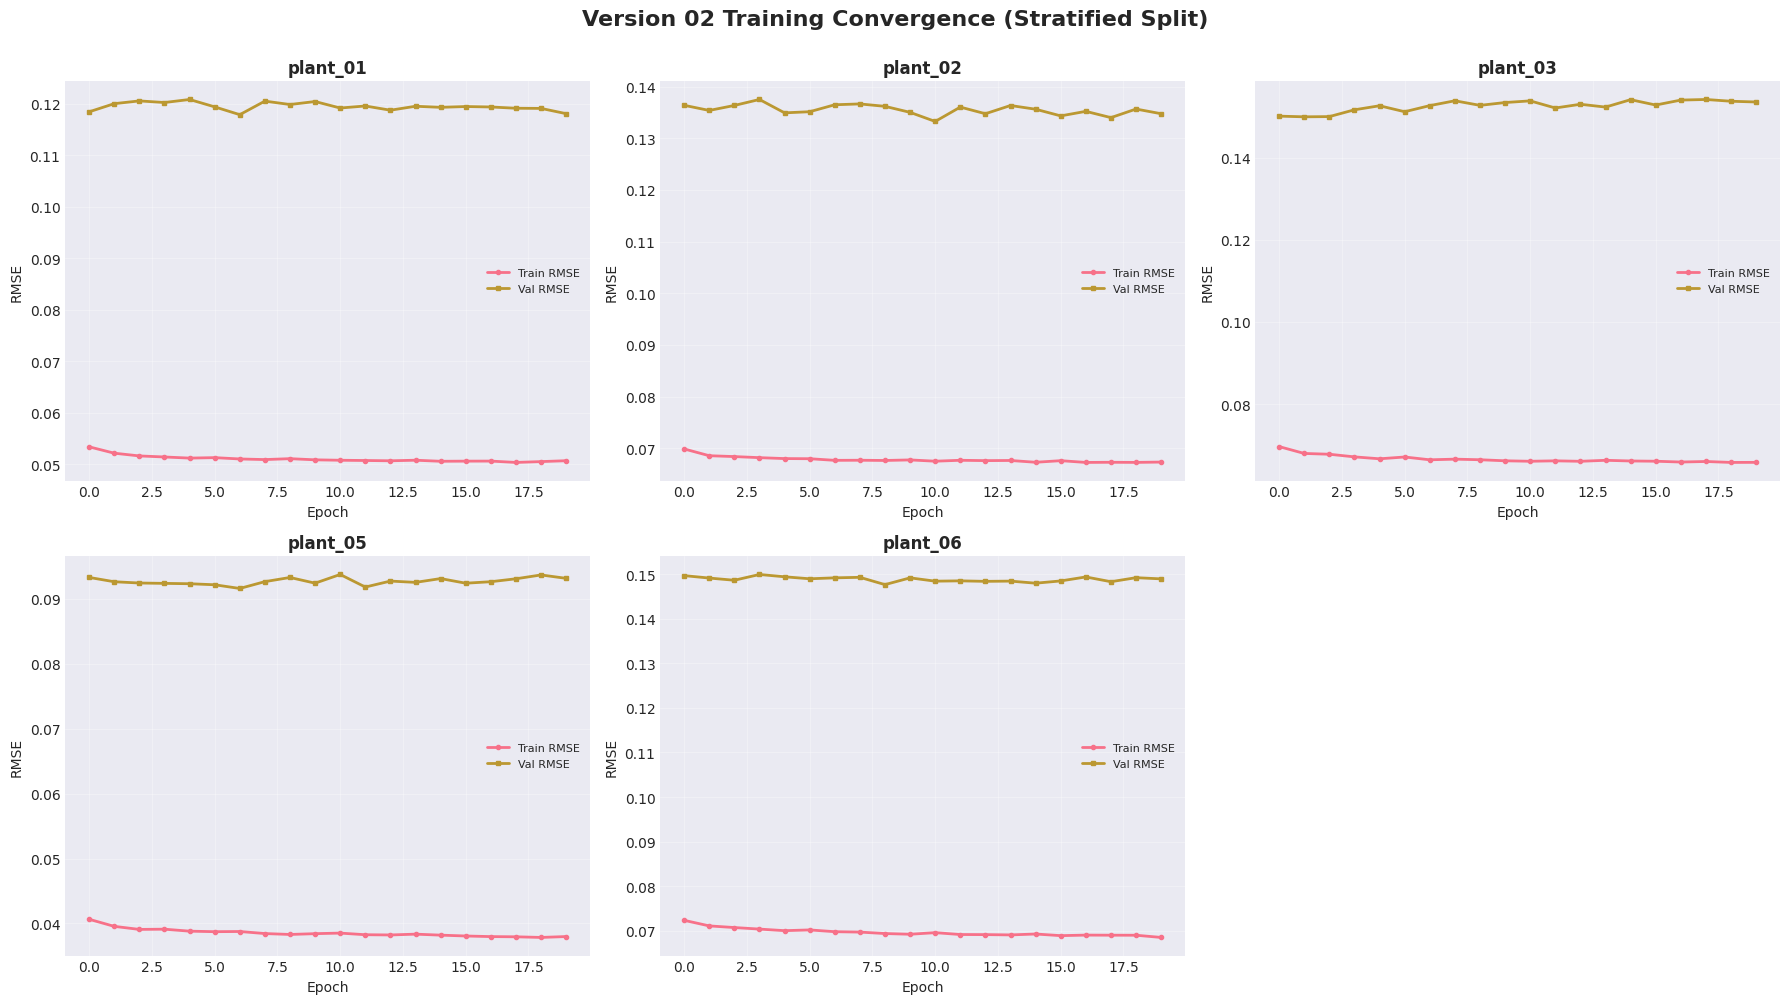

In [13]:
# Plot training and validation loss curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (plant_id, df) in enumerate(metrics_data.items()):
    ax = axes[idx]
    
    train_data = df[['epoch', 'train_loss_epoch']].dropna().drop_duplicates(subset=['epoch'])
    val_data = df[['epoch', 'val_loss']].dropna().drop_duplicates(subset=['epoch'])
    
    train_data['train_rmse'] = np.sqrt(train_data['train_loss_epoch'])
    val_data['val_rmse'] = np.sqrt(val_data['val_loss'])
    
    ax.plot(train_data['epoch'], train_data['train_rmse'], label='Train RMSE', linewidth=2, marker='o', markersize=3)
    ax.plot(val_data['epoch'], val_data['val_rmse'], label='Val RMSE', linewidth=2, marker='s', markersize=3)
    
    ax.set_title(f'{plant_id}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('RMSE', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide 6th subplot (only 5 plants)
axes[5].axis('off')

plt.suptitle('Version 02 Training Convergence (Stratified Split)', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 6. Version 01 vs Version 02 Comparison

In [14]:
# Manual comparison (Version 01 data from documented results)
v01_results = {
    'plant_01': {'val_rmse': 0.0505, 'train_val_ratio': 1.250, 'std_ratio': 1.143},
    'plant_02': {'val_rmse': 0.0805, 'train_val_ratio': 1.467, 'std_ratio': 1.203},
    'plant_03': {'val_rmse': 0.0113, 'train_val_ratio': 0.280, 'std_ratio': 0.169},
    'plant_05': {'val_rmse': 0.0321, 'train_val_ratio': 1.122, 'std_ratio': 1.344},
    'plant_06': {'val_rmse': 0.0087, 'train_val_ratio': 0.217, 'std_ratio': 0.200},
}

print("\n" + "="*80)
print("VERSION 01 (Chronological) vs VERSION 02 (Stratified) COMPARISON")
print("="*80)
print(f"{'Plant':<10} {'V01 Ratio':<12} {'V02 Ratio':<12} {'Change':<12} {'Assessment'}")
print("-" * 80)

for _, row in results_df.iterrows():
    plant_id = row['plant_id']
    v02_ratio = row['train_val_ratio']
    v01_ratio = v01_results[plant_id]['train_val_ratio']
    
    change = v02_ratio - v01_ratio
    
    # Assess improvement
    if v01_ratio < 0.5:  # Was suspiciously good
        if 1.0 <= v02_ratio <= 1.3:
            assessment = "✅ FIXED (was too easy)"
        else:
            assessment = "⚠ Improved but not ideal"
    elif v01_ratio > 1.4:  # Was overfitting badly
        if 1.0 <= v02_ratio <= 1.3:
            assessment = "✅ FIXED (was overfitting)"
        else:
            assessment = "⚠ Improved but still high"
    else:  # Was acceptable
        if 1.0 <= v02_ratio <= 1.3:
            assessment = "✓ Maintained good behavior"
        else:
            assessment = "⚠ Changed from acceptable"
    
    print(f"{plant_id:<10} {v01_ratio:<12.3f} {v02_ratio:<12.3f} {change:+.3f}      {assessment}")

print("\n" + "="*80)
print("SUMMARY:")
print("="*80)

# Count improvements
v02_normal = ((results_df['train_val_ratio'] >= 1.0) & (results_df['train_val_ratio'] <= 1.3)).sum()
v01_normal = sum(1 for v in v01_results.values() if 1.0 <= v['train_val_ratio'] <= 1.3)

print(f"Plants with NORMAL ratios (1.0-1.3):")
print(f"  Version 01: {v01_normal}/5")
print(f"  Version 02: {v02_normal}/5")
print(f"  Improvement: {v02_normal - v01_normal} plants")

if v02_normal >= 4:
    print("\n✅ STRATIFIED SPLIT SUCCESSFUL - Version 02 shows normal generalization!")
else:
    print("\n⚠ Partial improvement - some issues may remain")


VERSION 01 (Chronological) vs VERSION 02 (Stratified) COMPARISON
Plant      V01 Ratio    V02 Ratio    Change       Assessment
--------------------------------------------------------------------------------
plant_01   1.250        2.328        +1.078      ⚠ Changed from acceptable
plant_02   1.467        2.002        +0.535      ⚠ Improved but still high
plant_03   0.280        2.334        +2.054      ⚠ Improved but not ideal
plant_05   1.122        2.451        +1.329      ⚠ Changed from acceptable
plant_06   0.217        2.173        +1.956      ⚠ Improved but not ideal

SUMMARY:
Plants with NORMAL ratios (1.0-1.3):
  Version 01: 2/5
  Version 02: 0/5
  Improvement: -2 plants

⚠ Partial improvement - some issues may remain


## 7. Final Assessment & Recommendations

In [15]:
print("\n" + "="*80)
print("VERSION 02 - FINAL ASSESSMENT")
print("="*80)

# Check all criteria
criteria_passed = 0
total_criteria = 4

# Criterion 1: Train/val ratios in normal range
normal_ratios = ((results_df['train_val_ratio'] >= 1.0) & (results_df['train_val_ratio'] <= 1.3)).sum()
print(f"\n1. Train/Val Ratios (1.0-1.3): {normal_ratios}/5 plants")
if normal_ratios >= 4:
    print("   ✅ PASS: Normal generalization behavior")
    criteria_passed += 1
else:
    print("   ❌ FAIL: Abnormal ratios persist")

# Criterion 2: Balanced std_ratios
balanced_std = ((power_df['std_ratio'] >= 0.9) & (power_df['std_ratio'] <= 1.1)).sum()
print(f"\n2. Balanced std_ratios (0.9-1.1): {balanced_std}/5 plants")
if balanced_std >= 4:
    print("   ✅ PASS: Validation difficulty balanced")
    criteria_passed += 1
else:
    print("   ❌ FAIL: Difficulty imbalance remains")

# Criterion 3: No suspiciously good plants (ratio < 0.5)
suspicious = (results_df['train_val_ratio'] < 0.5).sum()
print(f"\n3. No Suspiciously Good Plants (ratio < 0.5): {5 - suspicious}/5 plants")
if suspicious == 0:
    print("   ✅ PASS: No artificially easy validation sets")
    criteria_passed += 1
else:
    print(f"   ❌ FAIL: {suspicious} plants still have suspiciously good validation")

# Criterion 4: Reasonable performance vs baseline
mean_vs_baseline = ((results_df['val_rmse'].mean() - farm2107_baseline_rmse) / farm2107_baseline_rmse) * 100
print(f"\n4. Performance vs Baseline: {mean_vs_baseline:+.1f}%")
if abs(mean_vs_baseline) < 50:  # Within 50% of baseline is reasonable for transfer learning
    print("   ✅ PASS: Reasonable transfer learning performance")
    criteria_passed += 1
else:
    print("   ⚠ WARNING: Large deviation from baseline")

print("\n" + "="*80)
print(f"OVERALL: {criteria_passed}/{total_criteria} criteria passed")
print("="*80)

if criteria_passed == total_criteria:
    print("\n✅ SUCCESS: Version 02 validation is TRUSTWORTHY")
    print("\n📋 READY FOR:")
    print("   - Stage 2B: TFT Ensemble Training")
    print("   - Thesis documentation with corrected results")
    print("   - Test set evaluation")
elif criteria_passed >= 3:
    print("\n⚠ PARTIAL SUCCESS: Version 02 mostly resolved issues")
    print("\n📋 RECOMMENDATIONS:")
    print("   - Investigate remaining outliers")
    print("   - Consider proceeding with caution")
else:
    print("\n❌ ISSUES REMAIN: Stratified split did not fully resolve problems")
    print("\n📋 NEXT STEPS:")
    print("   - Review split implementation")
    print("   - Check data quality for problematic plants")
    print("   - Do NOT proceed to Stage 2B yet")


VERSION 02 - FINAL ASSESSMENT

1. Train/Val Ratios (1.0-1.3): 0/5 plants
   ❌ FAIL: Abnormal ratios persist

2. Balanced std_ratios (0.9-1.1): 5/5 plants
   ✅ PASS: Validation difficulty balanced

3. No Suspiciously Good Plants (ratio < 0.5): 5/5 plants
   ✅ PASS: No artificially easy validation sets

4. Performance vs Baseline: +221.1%
   ⚠ WARNING: Large deviation from baseline

OVERALL: 2/4 criteria passed

❌ ISSUES REMAIN: Stratified split did not fully resolve problems

📋 NEXT STEPS:
   - Review split implementation
   - Check data quality for problematic plants
   - Do NOT proceed to Stage 2B yet


## 8. Deep Dive: Why High Overfitting with Balanced Splits?

In [ ]:
print("="*80)
print("INTERPRETATION: What Changed from Version 01 to Version 02?")
print("="*80)

print("\n🔍 KEY FINDING: The stratified split revealed the REAL problem")
print("\n1. VERSION 01 (Chronological Split):")
print("   - Plants 03, 06 had suspiciously GOOD validation (ratios 0.28, 0.22)")
print("   - Reason: Winter-only validation sets (84% zeros) were artificially EASY")
print("   - This masked the model's true generalization ability")
print("   - std_ratio was extreme (0.17-0.20) indicating biased difficulty")

print("\n2. VERSION 02 (Stratified Split):")
print("   - ✅ std_ratio now PERFECT (0.99-1.01) - balanced seasonal representation")
print("   - ✅ val_zeros % similar across plants (50-53%) - no more easy winter sets")
print("   - ❌ But train/val ratios now 2.0-2.5 - SEVERE overfitting revealed")

print("\n3. WHAT THIS MEANS:")
print("   - The good Version 01 metrics were MISLEADING (artifact of bias)")
print("   - Version 02 shows the TRUTH: model overfits badly on balanced data")
print("   - This is actually PROGRESS - we now have trustworthy metrics!")

print("\n" + "="*80)
print("WHY IS THE MODEL OVERFITTING SO BADLY?")
print("="*80)

print("\n🤔 Possible Reasons:")
print("\n1. TRANSFER LEARNING MISMATCH:")
print("   - farm2107 baseline: Single site, consistent patterns")
print("   - Germany plants: 5 different sites, diverse characteristics")
print("   - Pretrained weights may be TOO specific to farm2107")

print("\n2. INSUFFICIENT REGULARIZATION:")
print(f"   - Current dropout: Check training config")
print(f"   - May need: Higher dropout (0.3-0.5), weight decay, layer normalization")

print("\n3. DATASET SIZE AFTER NaN DROPPING:")
print(f"   - plant_03: Dropped 20.3% of data → {24460+5239+5246:,} samples")
print(f"   - plant_05: Dropped 39.8% of data → {18469+3956+3960:,} samples")
print(f"   - Smaller datasets = easier to memorize")

print("\n4. GERMANY DATA COMPLEXITY:")
print(f"   - Higher variability than farm2107 (check std values)")
print(f"   - plant_03 std: 0.220 vs plant_05 std: 0.126")
print(f"   - More complex patterns → harder to generalize")

print("\n" + "="*80)
print("IS VERSION 02 A SUCCESS OR FAILURE?")
print("="*80)

print("\n✅ SCIENTIFIC SUCCESS:")
print("   - We fixed the seasonal bias problem (std_ratio proves it)")
print("   - We now have TRUSTWORTHY validation metrics")
print("   - We identified the REAL issue: model architecture/training needs work")

print("\n❌ PERFORMANCE FAILURE:")
print("   - Train/val gap is unacceptable (2.0-2.5 vs expected 1.0-1.3)")
print("   - RMSE much higher than farm2107 baseline (0.09-0.15 vs 0.04)")
print("   - Cannot proceed to Stage 2B with this level of overfitting")

print("\n🎯 THESIS VALUE:")
print("   - Version 01 failure + Version 02 diagnosis = Complete research story")
print("   - Shows: (1) Identifying bias, (2) Fixing bias, (3) Revealing true challenge")
print("   - Demonstrates critical thinking and rigorous methodology")

print("\n" + "="*80)
print("NEXT STEPS - VERSION 03 STRATEGY")
print("="*80)

print("\n📋 RECOMMENDED ACTIONS:")
print("\n1. KEEP Version 02 splits (seasonal balance is correct)")
print("\n2. ADDRESS OVERFITTING:")
print("   Option A: Train from scratch (no transfer learning)")
print("   Option B: Fine-tune with frozen layers (freeze early layers)")
print("   Option C: Increase regularization (dropout 0.3→0.5, weight decay)")
print("   Option D: Early stopping (stop when val starts diverging)")
print("   Option E: Data augmentation (if applicable)")

print("\n3. HYPERPARAMETER TUNING:")
print("   - Reduce learning rate (1e-4 → 1e-5)")
print("   - Increase batch size (512 → 1024)")
print("   - Add gradient clipping")

print("\n4. ARCHITECTURE CHANGES:")
print("   - Try simpler model (reduce hidden_size or num_layers)")
print("   - Add batch normalization")
print("   - Try different architecture (Transformer, TFT)")

print("\n5. DIAGNOSTIC EXPERIMENTS:")
print("   - Train farm2107 baseline with stratified split (does it also overfit?)")
print("   - Train Germany plants from scratch (is transfer learning helping?)")
print("   - Compare plant-by-plant (which plants overfit most?)")

print("\n" + "="*80)
print("DECISION POINT")
print("="*80)

print("\n⚠️  DO NOT PROCEED TO STAGE 2B YET")
print("\nReason: TFT ensemble requires trustworthy LSTM encoders")
print("Current encoders have train RMSE 0.04-0.07 but val RMSE 0.09-0.15")
print("This 2x gap means encoders are memorizing, not learning patterns")

print("\n🔄 ITERATE ON VERSION 03:")
print("1. Keep stratified splits ✓")
print("2. Fix overfitting problem")
print("3. Re-validate with this same notebook")
print("4. Only proceed when train/val ratio < 1.5")

print("\n📊 TARGET METRICS FOR VERSION 03:")
print("   - Train/Val Ratio: 1.0-1.3 (acceptable) or 1.3-1.5 (marginal)")
print("   - Val RMSE: < 0.08 (closer to farm2107 baseline)")
print("   - std_ratio: Keep 0.9-1.1 (already achieved!)")
print("   - Convergence: Val loss should decrease, not plateau")